<h1>1. Exploratory Data Analysis </h1>

In [1]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from subprocess import check_output
%matplotlib inline
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
import os
import gc

import re
from nltk.corpus import stopwords
import distance
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup

<h2> 1.1 Reading data and basic stats </h2>

In [2]:
df = pd.read_csv("Twitter_Data.csv")

print("Number of data points:",df.shape[0])

Number of data points: 162980


In [3]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


<h3> 3.2.1 Distribution of data points among output classes</h3>
- Number of duplicate(smilar) and non-duplicate(non similar) questions

<AxesSubplot:xlabel='category'>

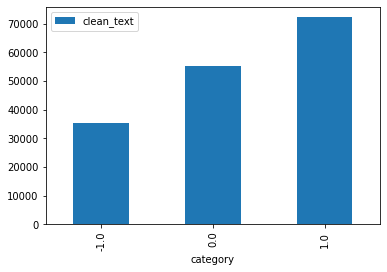

In [6]:
df.groupby("category").count().plot.bar()

In [25]:
print(f"The total number of data points are {df.shape[0]}")
print(f"the percentage of positive pair points are {df.groupby('category').count()['clean_text'][1]/len(df)} ")
print(f"the percentage of neutral pair points are {df.groupby('category').count()['clean_text'][0]/len(df)}")
print(f"the percentage of negative pair points are {df.groupby('category').count()['clean_text'][-1]/len(df)}")

The total number of data points are 162980
the percentage of positive pair points are 0.44329979138544606 
the percentage of neutral pair points are 0.3387593569763161
the percentage of negative pair points are 0.21787335869431831


We have the positive tweets in majority amount as compared to negative and neutal tweets
The sum of negative and neutral tweets are greater than the positive tweets

In [21]:
df.groupby('category').count()['clean_text']

category
-1.0    35509
 0.0    55211
 1.0    72249
Name: clean_text, dtype: int64

<h3> 1.2.1 Checking for NULL values </h3>

In [43]:
nan_rows = df[df.isnull().any(1)]
print(nan_rows)

                                               clean_text  category
148                                                   NaN       0.0
130448  the foundation stone northeast gas grid inaugu...       NaN
155642  dear terrorists you can run but you cant hide ...       NaN
155698  offense the best defence with mission shakti m...       NaN
155770  have always heard politicians backing out thei...       NaN
158693  modi government plans felicitate the faceless ...       NaN
158694                                                NaN      -1.0
159442               chidambaram gives praises modinomics       NaN
159443                                                NaN       0.0
160559  the reason why modi contested from seats 2014 ...       NaN
160560                                                NaN       1.0


There are two ways to handle nan values, either by deleting the rows or by replacing it with some new data, since the number of nan rows is less than 1 percent of whole data, i will delete those rows

In [44]:
df.dropna(axis = 0, inplace =True, how='any')

# <h3> 1.2.2 Number of unique tweets </h3>

In [36]:
print(f"The number of unique tweets {len(df['clean_text'].value_counts())}")
print(f" the total number of tweets in dataframe  {df.shape[0]}")

The number of unique tweets 162976
 the total number of tweets in dataframe  162980


<h2>1.2 Basic Feature Extraction (before cleaning) </h2>

Let us now construct a few features like:
 - ____len____ = Length of tweet
 - ____words____ = Number of words in tweet

In [55]:
if os.path.isfile('df_fe_without_preprocessing_train.csv'):
    df = pd.read_csv("df_fe_without_preprocessing_train.csv",encoding='latin-1')
else:
    df['len'] = df['clean_text'].str.len() 
    df['words'] = df['clean_text'].apply(lambda row: len(row.split(" ")))
    df.to_csv("df_fe_without_preprocessing_train.csv", index=False)

df.head()

,clean_text,category,len,words
0,when modi promised “minimum government maximum...,-1.0,210,33
1,talk all the nonsense and continue all the dra...,0.0,68,14
2,what did just say vote for modi welcome bjp t...,1.0,117,23
3,asking his supporters prefix chowkidar their n...,1.0,212,34
4,answer who among these the most powerful world...,1.0,81,15


<h3> 3.2.1 Analysis of some of the extracted features </h3>

In [57]:
print ("Minimum length of the tweet : " , min(df['len']))
print ("Maximum length of the tweet : " , max(df['len']))


print ("Number of tweets with minimum length tweets :", df[df['len']==min(df['len']) ].shape[0])
print ("Number of tweets with Maxomum length tweets :", df[df['len']== max(df['len'])].shape[0])

Minimum length of the tweet :  1
Maximum length of the tweet :  274
Number of tweets with minimum length tweets : 1
Number of tweets with Maxomum length tweets : 1


In [58]:
print ("Minimum  word length of the tweet : " , min(df['words']))
print ("Maximum word length of the tweet : " , max(df['words']))


print ("Number of tweets with minimum word  length tweets :", df[df['words']==min(df['words']) ].shape[0])
print ("Number of tweets with Maxomum  word  length tweets :", df[df['words']== max(df['words'])].shape[0])

Minimum  word length of the tweet :  1
Maximum word length of the tweet :  52
Number of tweets with minimum word  length tweets : 89
Number of tweets with Maxomum  word  length tweets : 2


<Figure size 720x720 with 0 Axes>

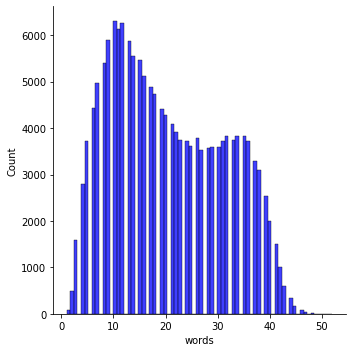

In [62]:
plt.figure(figsize=(10,10))
sns.displot(df['words'] , label = "0" , color = 'blue' )
plt.show()

<h2> 2. Preprocessing of Text </h2>

In [65]:
import warnings
warnings.filterwarnings("ignore")


import re
from nltk.corpus import stopwords
import distance
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup
import re
from nltk.corpus import stopwords

import distance
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup
from fuzzywuzzy import fuzz
from sklearn.manifold import TSNE

from wordcloud import WordCloud, STOPWORDS
from os import path
from PIL import Image

In [114]:

if os.path.isfile('df_fe_without_preprocessing_train.csv'):
    df = pd.read_csv("df_fe_without_preprocessing_train.csv",encoding='latin-1')
    df = df.fillna('')
    df.head()
else:
    print("get df_fe_without_preprocessing_train.csv from drive or run the previous notebook")

In [115]:
df.head()

,clean_text,category,len,words
0,when modi promised âminimum government maxim...,-1.0,210,33
1,talk all the nonsense and continue all the dra...,0.0,68,14
2,what did just say vote for modi welcome bjp t...,1.0,117,23
3,asking his supporters prefix chowkidar their n...,1.0,212,34
4,answer who among these the most powerful world...,1.0,81,15


- Preprocessing:
    - Removing html tags 
    - Removing Punctuations
    - Performing stemming
    - Removing Stopwords
    - Expanding contractions etc.

In [175]:
# To get the results in 4 decemal points
SAFE_DIV = 0.0001 

STOP_WORDS = set(stopwords.words("english"))


def preprocess(x):
    x = str(x).lower()
    x = x.replace(",000,000", "m").replace(",000", "k").replace("′", "'").replace("’", "'")\
                           .replace("won't", "will not").replace("cannot", "can not").replace("can't", "can not")\
                           .replace("n't", " not").replace("what's", "what is").replace("it's", "it is")\
                           .replace("'ve", " have").replace("i'm", "i am").replace("'re", " are")\
                           .replace("he's", "he is").replace("she's", "she is").replace("'s", " own")\
                           .replace("%", " percent ").replace("₹", " rupee ").replace("$", " dollar ")\
                           .replace("€", " euro ").replace("'ll", " will")
    x = re.sub(r"([0-9]+)000000", r"\1m", x)
    x = re.sub(r"([0-9]+)000", r"\1k", x)
    if x=="":
        x ="hola"
    
    porter = PorterStemmer()
    pattern = re.compile('\W')
    
    if type(x) == type(''):
        x = re.sub(pattern, ' ', x)
    
    
    if type(x) == type(''):
        x = porter.stem(x)
        example1 = BeautifulSoup(x)
        x = example1.get_text()
               
    
    return x
    

In [176]:
def extract_features(df):
    # preprocessing each tweet
    df["clean_text"] = df["clean_text"].fillna(" ").apply(preprocess)
    return df

In [177]:
df = extract_features(df)
df.head()

,clean_text,category,len,words
0,when modi promised â minimum government maxim...,-1.0,210,33
1,talk all the nonsense and continue all the dra...,0.0,68,14
2,what did just say vote for modi welcome bjp t...,1.0,117,23
3,asking his supporters prefix chowkidar their n...,1.0,212,34
4,answer who among these the most powerful world...,1.0,81,15


__ Word Clouds generated from  duplicate pair question's text __

Word Cloud for Tweets


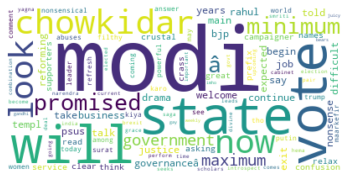

In [172]:
print ("Word Cloud for Tweets")
total_string = ' '.join(df['clean_text'].values[:10])
word_cloud = WordCloud(collocations = False, background_color = 'white').generate(total_string)
plt.imshow(word_cloud, interpolation='bilinear')

plt.axis("off")
plt.show()

In [179]:
df.head()

,clean_text,category,len,words
0,when modi promised â minimum government maxim...,-1.0,210,33
1,talk all the nonsense and continue all the dra...,0.0,68,14
2,what did just say vote for modi welcome bjp t...,1.0,117,23
3,asking his supporters prefix chowkidar their n...,1.0,212,34
4,answer who among these the most powerful world...,1.0,81,15


<h2> 3 Featurizing text data with tfidf weighted word-vectors </h2>

In [180]:
import spacy
from tqdm import tqdm

In [181]:
df['clean_text'] = df['clean_text'].apply(lambda x: str(x))
df.head()

,clean_text,category,len,words
0,when modi promised â minimum government maxim...,-1.0,210,33
1,talk all the nonsense and continue all the dra...,0.0,68,14
2,what did just say vote for modi welcome bjp t...,1.0,117,23
3,asking his supporters prefix chowkidar their n...,1.0,212,34
4,answer who among these the most powerful world...,1.0,81,15


In [182]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
tweets = df['clean_text'].tolist()

tfidf = TfidfVectorizer(lowercase=False, )
tfidf.fit_transform(tweets)
# dict key:word and value:tf-idf score
word2tfidf = dict(zip(tfidf.get_feature_names(), tfidf.idf_))


- After we find TF-IDF scores, we convert each tweet to a weighted average of word2vec vectors by these scores.
- here we use a pre-trained GLOVE model which comes free with "Spacy".  
- It is trained on Wikipedia and therefore, it is stronger in terms of word semantics. 

In [183]:
# en_vectors_web_lg, which includes over 1 million unique vectors.
nlp = spacy.load('en_core_web_sm')

vecs1 = []
# https://github.com/noamraph/tqdm
# tqdm is used to print the progress bar
for qu1 in tqdm(list(df['clean_text'])):

    doc1 = nlp(qu1) 

    # 384 is the number of dimensions of vectors 
    mean_vec1 = np.zeros([len(doc1), len(doc1[0].vector)])
    for word1 in doc1:
        # word2vec
        vec1 = word1.vector
        # fetch df score
        try:
            idf = word2tfidf[str(word1)]
        except:
            idf = 0
        # compute final vec
        mean_vec1 += vec1 * idf
    mean_vec1 = mean_vec1.mean(axis=0)
    vecs1.append(mean_vec1)
df['tweet_feats_m'] = list(vecs1)


100%|██████████████████████████████████████████████████████████████████████████| 162969/162969 [34:46<00:00, 78.10it/s]


In [196]:
df.head()

,clean_text,category,len,words,tweet_feats_m
0,when modi promised â minimum government maxim...,-1.0,210,33,"[107.56868189573288, 23.9895980656147, 0.25312..."
1,talk all the nonsense and continue all the dra...,0.0,68,14,"[10.77702271938324, 2.555596314370632, -7.2433..."
2,what did just say vote for modi welcome bjp t...,1.0,117,23,"[-11.200371578335762, -5.969201554195024, 8.11..."
3,asking his supporters prefix chowkidar their n...,1.0,212,34,"[-23.280624508857727, 0.23381423950195312, -7...."
4,answer who among these the most powerful world...,1.0,81,15,"[39.4338590875268, 22.696142364293337, 21.2884..."


In [187]:
if os.path.isfile('nlp_features_train.csv'):
    dfnlp = pd.read_csv("nlp_features_train.csv",encoding='latin-1')
else:
    print("download nlp_features_train.csv from drive or run previous notebook")

if os.path.isfile('df_fe_without_preprocessing_train.csv'):
    dfppro = pd.read_csv("df_fe_without_preprocessing_train.csv",encoding='latin-1')

download nlp_features_train.csv from drive or run previous notebook


In [198]:
df.head()

,clean_text,category,len,words,tweet_feats_m
0,when modi promised â minimum government maxim...,-1.0,210,33,"[107.56868189573288, 23.9895980656147, 0.25312..."
1,talk all the nonsense and continue all the dra...,0.0,68,14,"[10.77702271938324, 2.555596314370632, -7.2433..."
2,what did just say vote for modi welcome bjp t...,1.0,117,23,"[-11.200371578335762, -5.969201554195024, 8.11..."
3,asking his supporters prefix chowkidar their n...,1.0,212,34,"[-23.280624508857727, 0.23381423950195312, -7...."
4,answer who among these the most powerful world...,1.0,81,15,"[39.4338590875268, 22.696142364293337, 21.2884..."


In [209]:
df2.head()

,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
0,107.568682,23.989598,0.253121,-0.927195,1.152630,70.337112,-13.928088,10.138905,-9.710313,-31.658191,...,-93.064554,-39.601645,-31.941871,-61.394087,-95.307414,9.703098,33.013344,11.808249,24.728847,-48.821229
1,10.777023,2.555596,-7.243305,-17.707911,-2.662892,18.598117,-1.330749,4.727710,2.119803,-8.288425,...,-1.667088,-22.201548,-10.276177,-5.374829,-4.375881,-5.045838,-19.154947,13.305160,3.772108,-1.113835
2,-11.200372,-5.969202,8.115156,-11.667489,-17.673988,49.925379,-33.888376,3.876889,8.221117,-29.465243,...,-22.599458,-13.500235,-17.791059,-21.993467,-24.245058,5.826658,-25.379006,1.897610,17.286042,-28.364110
3,-23.280625,0.233814,-7.650881,-33.547073,24.626445,67.466771,-17.415673,33.774649,32.819825,-3.620616,...,-36.333842,-24.336378,-42.946986,-16.232264,-78.338949,26.780740,-30.815563,56.225078,4.629447,-10.563962
4,39.433859,22.696142,21.288434,-5.007477,-17.635328,15.494762,-14.089673,19.183772,18.139818,-26.224769,...,-14.760736,-13.706588,-29.235569,-9.485894,-24.575558,1.372102,12.786111,-36.581115,38.050265,-19.224665


In [239]:
df1 = df.drop(['clean_text','tweet_feats_m'],axis=1)
df2 = pd.DataFrame()
df2[[str(i) for i in range(len(df['tweet_feats_m'][0]))]] = pd.DataFrame(df.tweet_feats_m.tolist(), index = df.index)


In [240]:
print("Number of features in nlp dataframe :", df1.shape[1])
print("Number of features in processed dataframe :", df2.shape[1])

print("Number of features in final dataframe  :", df1.shape[1]+df2.shape[1])

Number of features in nlp dataframe : 3
Number of features in processed dataframe : 96
Number of features in final dataframe  : 99


In [252]:
# storing the final features to csv file
if not os.path.isfile('final_features.csv'):
    result  = pd.merge(df1, df2,left_index = True,right_index=True)
    result.to_csv('final_features.csv', index = False)
else:
    result = pd.read_csv('final_features.csv',)

In [253]:
result.head()

,category,len,words,0,1,2,3,4,5,6,...,86,87,88,89,90,91,92,93,94,95
0,-1.0,210,33,107.568682,23.989598,0.253121,-0.927195,1.152630,70.337112,-13.928088,...,-93.064554,-39.601645,-31.941871,-61.394087,-95.307414,9.703098,33.013344,11.808249,24.728847,-48.821229
1,0.0,68,14,10.777023,2.555596,-7.243305,-17.707911,-2.662892,18.598117,-1.330749,...,-1.667088,-22.201548,-10.276177,-5.374829,-4.375881,-5.045838,-19.154947,13.305160,3.772108,-1.113835
2,1.0,117,23,-11.200372,-5.969202,8.115156,-11.667489,-17.673988,49.925379,-33.888376,...,-22.599458,-13.500235,-17.791059,-21.993467,-24.245058,5.826658,-25.379006,1.897610,17.286042,-28.364110
3,1.0,212,34,-23.280625,0.233814,-7.650881,-33.547073,24.626445,67.466771,-17.415673,...,-36.333842,-24.336378,-42.946986,-16.232264,-78.338949,26.780740,-30.815563,56.225078,4.629447,-10.563962
4,1.0,81,15,39.433859,22.696142,21.288434,-5.007477,-17.635328,15.494762,-14.089673,...,-14.760736,-13.706588,-29.235569,-9.485894,-24.575558,1.372102,12.786111,-36.581115,38.050265,-19.224665


# ML Models

In [243]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from scipy.sparse import hstack
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold 
from collections import Counter, defaultdict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import math
from sklearn.metrics import normalized_mutual_info_score
from sklearn.ensemble import RandomForestClassifier



from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
from mlxtend.classifier import StackingClassifier

from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc, roc_curve

In [255]:
result.head()

,category,len,words,0,1,2,3,4,5,6,...,86,87,88,89,90,91,92,93,94,95
0,-1.0,210,33,107.568682,23.989598,0.253121,-0.927195,1.152630,70.337112,-13.928088,...,-93.064554,-39.601645,-31.941871,-61.394087,-95.307414,9.703098,33.013344,11.808249,24.728847,-48.821229
1,0.0,68,14,10.777023,2.555596,-7.243305,-17.707911,-2.662892,18.598117,-1.330749,...,-1.667088,-22.201548,-10.276177,-5.374829,-4.375881,-5.045838,-19.154947,13.305160,3.772108,-1.113835
2,1.0,117,23,-11.200372,-5.969202,8.115156,-11.667489,-17.673988,49.925379,-33.888376,...,-22.599458,-13.500235,-17.791059,-21.993467,-24.245058,5.826658,-25.379006,1.897610,17.286042,-28.364110
3,1.0,212,34,-23.280625,0.233814,-7.650881,-33.547073,24.626445,67.466771,-17.415673,...,-36.333842,-24.336378,-42.946986,-16.232264,-78.338949,26.780740,-30.815563,56.225078,4.629447,-10.563962
4,1.0,81,15,39.433859,22.696142,21.288434,-5.007477,-17.635328,15.494762,-14.089673,...,-14.760736,-13.706588,-29.235569,-9.485894,-24.575558,1.372102,12.786111,-36.581115,38.050265,-19.224665


<h2> 4.3 Random train test split( 70:30) </h2>

In [254]:
y_true = list(map(int, result.category.values))

In [258]:
x_train,x_test, y_train,y_test = train_test_split(result.iloc[:,1:], y_true, stratify=y_true, test_size=0.3)

In [260]:
print("Number of data points in train data :",x_train.shape)
print("Number of data points in test data :",x_test.shape)

Number of data points in train data : (114078, 98)
Number of data points in test data : (48891, 98)


In [266]:
print("-"*10, "Distribution of output variable in train data", "-"*10)
train_distr = Counter(y_train)
train_len = len(y_train)
print("Class 1: ",int(train_distr[1])/train_len,"Class 0: ", int(train_distr[0])/train_len,"Class -1: ", int(train_distr[-1])/train_len)
print("-"*10, "Distribution of output variable in train data", "-"*10)
test_distr = Counter(y_test)
test_len = len(y_test)
print("Class 1: ",int(test_distr[1])/test_len, "Class 0: ",int(test_distr[0])/test_len,"Class -1: ",int(test_distr[-1])/test_len)

---------- Distribution of output variable in train data ----------
Class 1:  0.44332824909272606 Class 0:  0.33878574308806253 Class -1:  0.2178860078192114
---------- Distribution of output variable in train data ----------
Class 1:  0.44333312879671105 Class 0:  0.33877400748604036 Class -1:  0.21789286371724859


In [267]:
# This function plots the confusion matrices given y_i, y_i_hat.
def plot_confusion_matrix(test_y, predict_y):
    C = confusion_matrix(test_y, predict_y)
  
    
    A =(((C.T)/(C.sum(axis=1))).T)

    B =(C/C.sum(axis=0))
 
    plt.figure(figsize=(20,4))
    
    labels = [1,0,-1]
    # representing A in heatmap format
    cmap=sns.light_palette("blue")
    plt.subplot(1, 3, 1)
    sns.heatmap(C, annot=True, cmap=cmap, fmt=".3f", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title("Confusion matrix")
    
    plt.subplot(1, 3, 2)
    sns.heatmap(B, annot=True, cmap=cmap, fmt=".3f", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title("Precision matrix")
    
    plt.subplot(1, 3, 3)
    # representing B in heatmap format
    sns.heatmap(A, annot=True, cmap=cmap, fmt=".3f", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title("Recall matrix")
    
    plt.show()

<h2> 4.4 Building a random model (Finding worst-case log-loss) </h2>

Log loss on Test Data using Random Model 1.3416370254416339


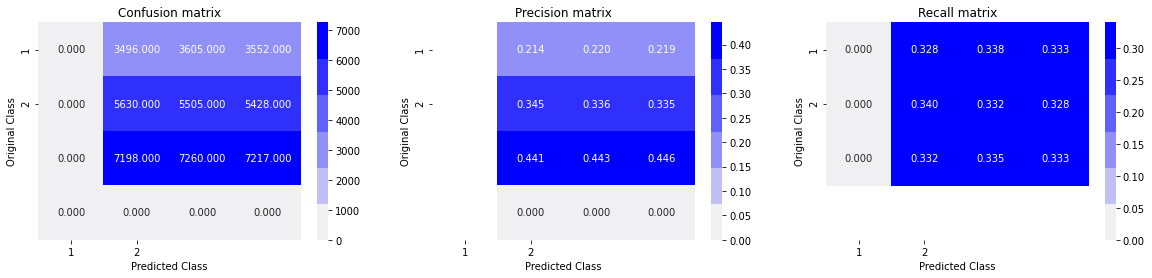

In [272]:
# we need to generate 9 numbers and the sum of numbers should be 1
# one solution is to genarate 9 numbers and divide each of the numbers by their sum
# ref: https://stackoverflow.com/a/18662466/4084039
# we create a output array that has exactly same size as the CV data
predicted_y = np.zeros((test_len,3))
for i in range(test_len):
    rand_probs = np.random.rand(1,3)
    predicted_y[i] = ((rand_probs/sum(sum(rand_probs)))[0])
print("Log loss on Test Data using Random Model",log_loss(y_test, predicted_y, eps=1e-15))

predicted_y =np.argmax(predicted_y, axis=1)
plot_confusion_matrix(y_test, predicted_y)

<h2> 4.4 Logistic Regression with hyperparameter tuning </h2>

For values of alpha =  1e-05 The log loss is: 0.956759485636966
For values of alpha =  0.0001 The log loss is: 0.953476843451268
For values of alpha =  0.001 The log loss is: 0.9341516473351028
For values of alpha =  0.01 The log loss is: 0.9286652027423433
For values of alpha =  0.1 The log loss is: 0.9200183044928727
For values of alpha =  1 The log loss is: 0.9218034460225112
For values of alpha =  10 The log loss is: 0.9403951043443874


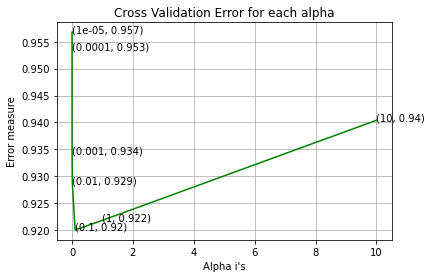

For values of best alpha =  0.1 The train log loss is: 0.9164284267469655
For values of best alpha =  0.1 The test log loss is: 0.9200183044928727
Total number of data points : 48891


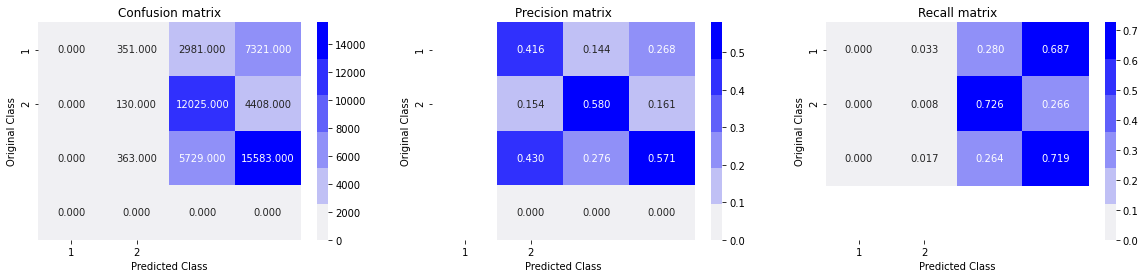

In [280]:
alpha = [10 ** x for x in range(-5, 2)] # hyperparam for SGD classifier.

log_error_array=[]
for i in alpha:
    clf = SGDClassifier(alpha=i, penalty='l2', loss='log', random_state=42)
    clf.fit(x_train, y_train)
    sig_clf = CalibratedClassifierCV(clf, method="sigmoid")
    sig_clf.fit(x_train, y_train)
    predict_y = sig_clf.predict_proba(x_test)
    log_error_array.append(log_loss(y_test, predict_y, labels=clf.classes_, eps=1e-15))
    print('For values of alpha = ', i, "The log loss is:",log_loss(y_test, predict_y, labels=clf.classes_, eps=1e-15))

fig, ax = plt.subplots()
ax.plot(alpha, log_error_array,c='g')
for i, txt in enumerate(np.round(log_error_array,3)):
    ax.annotate((alpha[i],np.round(txt,3)), (alpha[i],log_error_array[i]))
plt.grid()
plt.title("Cross Validation Error for each alpha")
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()


best_alpha = np.argmin(log_error_array)
clf = SGDClassifier(alpha=alpha[best_alpha], penalty='l2', loss='log', random_state=42)
clf.fit(x_train, y_train)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid")
sig_clf.fit(x_train, y_train)

predict_y = sig_clf.predict_proba(x_train)
print('For values of best alpha = ', alpha[best_alpha], "The train log loss is:",log_loss(y_train, predict_y, labels=clf.classes_, eps=1e-15))
predict_y = sig_clf.predict_proba(x_test)
print('For values of best alpha = ', alpha[best_alpha], "The test log loss is:",log_loss(y_test, predict_y, labels=clf.classes_, eps=1e-15))
predicted_y =np.argmax(predict_y,axis=1)
print("Total number of data points :", len(predicted_y))
plot_confusion_matrix(y_test, predicted_y)

<h2> 4.5 Linear SVM with hyperparameter tuning </h2>

For values of alpha =  1e-05 The log loss is: 0.9648131985366961
For values of alpha =  0.0001 The log loss is: 0.9552535912922138
For values of alpha =  0.001 The log loss is: 0.9373527683791852
For values of alpha =  0.01 The log loss is: 0.9243915935706944
For values of alpha =  0.1 The log loss is: 0.9382914151436609
For values of alpha =  1 The log loss is: 0.9744260390118228
For values of alpha =  10 The log loss is: 0.9998512814785192


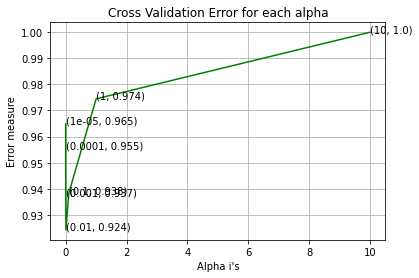

For values of best alpha =  0.01 The train log loss is: 0.9212827402710144
For values of best alpha =  0.01 The test log loss is: 0.9243915935706944
Total number of data points : 48891


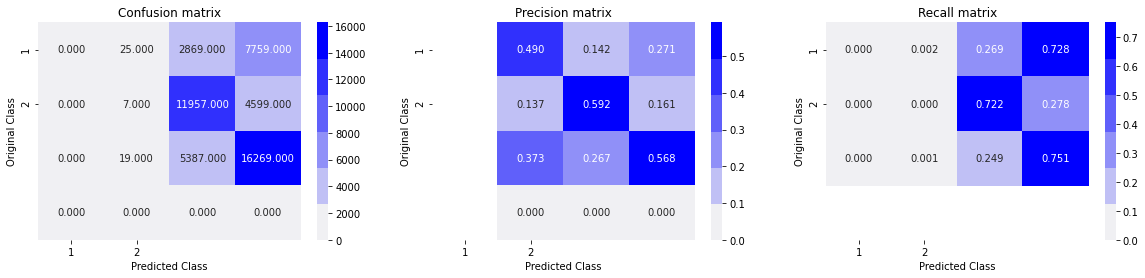

In [282]:
alpha = [10 ** x for x in range(-5, 2)] # hyperparam for SGD classifier.

log_error_array=[]
for i in alpha:
    clf = SGDClassifier(alpha=i, penalty='l1', loss='hinge', random_state=42)
    clf.fit(x_train, y_train)
    sig_clf = CalibratedClassifierCV(clf, method="sigmoid")
    sig_clf.fit(x_train, y_train)
    predict_y = sig_clf.predict_proba(x_test)
    log_error_array.append(log_loss(y_test, predict_y, labels=clf.classes_, eps=1e-15))
    print('For values of alpha = ', i, "The log loss is:",log_loss(y_test, predict_y, labels=clf.classes_, eps=1e-15))

fig, ax = plt.subplots()
ax.plot(alpha, log_error_array,c='g')
for i, txt in enumerate(np.round(log_error_array,3)):
    ax.annotate((alpha[i],np.round(txt,3)), (alpha[i],log_error_array[i]))
plt.grid()
plt.title("Cross Validation Error for each alpha")
plt.xlabel("Alpha i's")
plt.ylabel("Error measure")
plt.show()


best_alpha = np.argmin(log_error_array)
clf = SGDClassifier(alpha=alpha[best_alpha], penalty='l1', loss='hinge', random_state=42)
clf.fit(x_train, y_train)
sig_clf = CalibratedClassifierCV(clf, method="sigmoid")
sig_clf.fit(x_train, y_train)

predict_y = sig_clf.predict_proba(x_train)
print('For values of best alpha = ', alpha[best_alpha], "The train log loss is:",log_loss(y_train, predict_y, labels=clf.classes_, eps=1e-15))
predict_y = sig_clf.predict_proba(x_test)
print('For values of best alpha = ', alpha[best_alpha], "The test log loss is:",log_loss(y_test, predict_y, labels=clf.classes_, eps=1e-15))
predicted_y =np.argmax(predict_y,axis=1)
print("Total number of data points :", len(predicted_y))
plot_confusion_matrix(y_test, predicted_y)